In [44]:
import torch
from transformers import SegformerConfig, SegformerForSemanticSegmentation

print(f"PyTorch version: {torch.__version__}")
# Check if GPU is available
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0
Using device: mps


In [20]:

import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu

In [21]:
import rasterio
import numpy as np

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)
# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 0 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 0

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0

    return mask_np.astype(np.int64) # Masks are typically integer class labels


def crop_image_into_tiles(image_path, tile_size, is_image = False, overlap_pct = 0.25):
    """
    Loads an image from image_path, preprocesses it, and then crops it into tiles.

    Args:
        image_path (str): The path to the input image file.
        tile_size (int): The side length of the square tiles.

    Returns:
        list: A list of NumPy arrays, where each array is a cropped tile.
    """
    # Load and preprocess the image
    if is_image:
      img = load_and_preprocess(image_path)
    else:
      img = load_raw_mask(image_path)
    # Assuming img has shape (channels, height, width)
    channels, height, width = img.shape

    stride = int(tile_size * (1 - overlap_pct))

    tiles = []
    for y in range(0, height - tile_size + 1, stride):
        for x in range(0, width - tile_size + 1, stride):
            # Calculate end coordinates for the current tile
            x_end = min(x + tile_size, width)
            y_end = min(y + tile_size, height)

            # Crop the tile
            # Ensure the tile is of the exact `tile_size` by padding if necessary
            # or by taking the available portion if padding is not desired.
            # For simplicity, we'll just take what fits, potentially smaller edge tiles.
            tile = img[:, y:y_end, x:x_end]

            # If you want to ensure all tiles are `tile_size` x `tile_size` by padding,
            # you would add padding logic here. For this example, we'll keep it simple
            # and allow edge tiles to be smaller.
            tiles.append(tile)

    return tiles

print("Function `crop_image_into_tiles` defined.")

import os

def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

Function `crop_image_into_tiles` defined.


In [22]:

def contains_minority_class(label_path, threshold=0.2):
    """
    Checks if the percentage of pixels belonging to the minority class (Class 1)
    in a label mask is above a certain threshold.
    """
    mask_np_raw = load_raw_mask(label_path)
    # Apply the same remapping as in TrainingDataset to get the true class labels
    mask_np_raw[mask_np_raw == 2] = 0
    mask_np_raw[mask_np_raw == 3] = 0

    if(threshold == 0):
      return np.any(mask_np_raw == 1)

    count_class1 = np.sum(mask_np_raw == 1)
    total_pixels = mask_np_raw.size

    if total_pixels == 0:
        return False # Avoid division by zero

    percent_class1 = (count_class1 / total_pixels)

    return percent_class1 > threshold

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy


def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('dice_coef')
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks):
    # Corrected to 2 colors to match the 2 combined classes
    colors = np.asarray([(0, 255, 0), (0, 0, 255)]) # Green for class 0, Blue for class 1

    colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
    channels, height, width = masks.shape

    for y in range(height):
        for x in range(width):
            selected_colors = colors[masks[:,y,x] > 0.35] # Threshold for displaying class values

            if len(selected_colors) > 0:
                colorimg[y,x,:] = np.mean(selected_colors, axis=0)

    return colorimg.astype(np.uint8)


In [24]:
def masks_to_colorimg(masks, threshold = 0.5):
    # For binary segmentation with single-channel output representing the foreground class (road)
    # Input 'masks' is (1, H, W) for ground truth (0 or 1) or predictions (probabilities)

    # Create a 3-channel (RGB) image, initially white
    height, width = masks.shape[1], masks.shape[2]
    colorimg = np.ones((height, width, 3), dtype=np.float32) * 255

    # Define colors for background and foreground
    background_color = np.asarray([255, 255, 255]) # White for background
    foreground_color = np.asarray([0, 0, 255])   # Blue for road

    # Apply a threshold to determine foreground pixels
    # For ground truth masks, threshold effectively checks for value 1
    # For prediction masks, threshold applies to probabilities
    # Default threshold for predictions. For GT, any non-zero is foreground.

    # Assuming masks is (1, H, W), so we work with masks[0]
    foreground_pixels = masks[0] > threshold

    # Set color for foreground pixels
    colorimg[foreground_pixels] = foreground_color

    return colorimg.astype(np.uint8)


In [25]:
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import rasterio
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, num_classes=1): # Changed num_classes to 1
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform # This transform is for images
        self.num_classes = num_classes # Will always be 1 for binary segmentation
        print("using the one with binary segmentation")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        # Load image as NumPy array (C, H, W, float32) using the provided function
        image_np = load_and_preprocess(self.image_paths[index])
        image_np = np.ascontiguousarray(image_np) # Ensure image is contiguous in memory for PyTorch
        # Load mask as NumPy array (1, H, W, int64) using the new helper function
        mask_np_raw = load_raw_mask(self.label_paths[index])
        mask_np_raw = np.ascontiguousarray(mask_np_raw)
        
        # Apply class remapping: combine classes 2 and 3 into class 1, other non-zero to 1, all others to 0
        # Now we want a binary mask: 1 for road, 0 for background
        # Original values: 0 (background), 1 (road), 2 (sidewalk), 3 (bike lane)
        # We want: 1 (road), 0 (all others)
        mask_np_raw = np.where(mask_np_raw == 1, 1, 0).astype(np.int64, copy = True) # Only class 1 (road) becomes 1, everything else becomes 0
        #mask_np_raw = mask_np_raw # Ensure mask is int64 for PyTorch

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize
        if image_np.shape[0] == 3: # Assuming RGB
            # Multiply by 255 and convert to uint8 before creating PIL Image
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            image_tensor = transforms.ToTensor()(image_pil)

        image_tensor = image_tensor.contiguous() # Ensure memory layout is contiguous for later operations
        # Determine the target size for the mask from the transformed image
        target_size = image_tensor.shape[-2:] # Get (H, W) from the image tensor

        # Convert raw mask (1, H, W) to PyTorch Tensor (float32 for BCEWithLogitsLoss)
        # Changed to .long() as CrossEntropyLoss expects Long type for labels
        mask_tensor = torch.from_numpy(mask_np_raw).long().contiguous()
        #mask_tensor = mask_tensor.contiguous() # Ensure memory layout is contiguous for later operations

        # Resize the mask using nearest neighbor interpolation
        # Ensure mask_tensor is (C, H, W) for Resize, then (1, H, W) float
        mask_resized = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
            mask_tensor
        )

        # Squeeze the channel dimension to get (H, W) for CrossEntropyLoss
        mask_resized = mask_tensor.squeeze(0).float()
        
        # For binary segmentation, the target should be a single-channel float tensor
        # (N, H, W). Our mask_resized is (H, W) after squeezing, so it's ready.
        return {"pixel_values": image_tensor.float().contiguous(), "labels": mask_resized.long().contiguous()}

print("TrainingDataset class defined for binary segmentation.")

TrainingDataset class defined for binary segmentation.


In [45]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, path = '/Users/yujiewu/SP/bogota-roads-filtered'):
    base_path = path
    image_dir = os.path.join(base_path, 'images')
    label_dir = os.path.join(base_path, 'labels')

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*.tif')))

    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    # Pair image and label paths
    all_pairs = list(zip(all_image_paths, all_label_paths))

    # Split all pairs into training and validation sets
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    if subset_size is not None:
        final_train_pairs = train_pairs[:subset_size]#final_train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4] # Keep validation subset smaller if train is subsetted
    #else:
    #  val_pairs = val_pairs[:len(final_train_pairs) // 4]
    train_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
    train_label_paths = [p[1] for p in train_pairs]#final_train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images (using pre-undersampled drive): {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    # Define image transformations
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_size = (256, 256) # Define target image size, further reduced for faster verification
    #print(f"get_data_loaders: Setting image_size to {image_size}")

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        transform=train_transform
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False #bc using mps
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False #bc using mps
    )

    return {'train': train_dataset, 'val': val_dataset}
    #return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined with undersampling capability.")


Function `get_data_loaders` defined with undersampling capability.


#Model Setup

In [27]:
from torchvision.transforms import ColorJitter
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor()
'''
jitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1)

def train_transforms(example_batch):
    images = [jitter(x) for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = processor(images, labels)
    return inputs


# Set transforms
train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)
'''

"\njitter = ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1)\n\ndef train_transforms(example_batch):\n    images = [jitter(x) for x in example_batch['pixel_values']]\n    labels = [x for x in example_batch['label']]\n    inputs = processor(images, labels)\n    return inputs\n\n\ndef val_transforms(example_batch):\n    images = [x for x in example_batch['pixel_values']]\n    labels = [x for x in example_batch['label']]\n    inputs = processor(images, labels)\n    return inputs\n\n\n# Set transforms\ntrain_ds.set_transform(train_transforms)\ntest_ds.set_transform(val_transforms)\n"

In [46]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"

# Define ID to Label and Label to ID mappings for binary segmentation
id2label = {0: "background", 1: "road"}
label2id = {"background": 0, "road": 1}
num_labels = len(id2label)

model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

In [47]:
from transformers import TrainingArguments

epochs = 1 #50 #365 steps per epoch
lr = 0.00006
batch_size = 2

hub_model_id = "segformer-road-separation"

training_args = TrainingArguments(
    #"segformer-b0-finetuned-segments-sidewalk-outputs",
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=False, 
    hub_model_id=hub_model_id,
    hub_strategy="end",
    remove_unused_columns=False, # Added to prevent TypeError with custom dataset
    use_cpu=False,          # <-- force CPU
)

In [31]:
import datasets, evaluate
print(datasets.__version__, evaluate.__version__)
print(datasets.__file__)

4.8.4 0.4.6
/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/datasets/__init__.py


In [48]:
import torch
from torch import nn
import evaluate

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).contiguous().argmax(dim=1)

    pred_labels = logits_tensor.detach().cpu().numpy()
    metrics = metric.compute(
        predictions=pred_labels,
        references=labels,
        num_labels=len(id2label),
        ignore_index=0,
        reduce_labels=processor.do_reduce_labels,
    )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics


In [49]:
from transformers import Trainer
import torch
class ContiguousTrainer(Trainer):
    def training_step(self, model, inputs, num_items_in_batch=None):
        # Inspect what Accelerate passed in
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor):
                print(f"{k}: shape={v.shape}, dtype={v.dtype}, "
                      f"contiguous={v.is_contiguous()}, "
                      f"device={v.device}, "
                      f"stride={v.stride()}")
        
        inputs = {
            k: v.contiguous() if isinstance(v, torch.Tensor) else v
            for k, v in inputs.items()
        }
        return super().training_step(model, inputs, num_items_in_batch)

In [50]:
from transformers import Trainer
from huggingface_hub import notebook_login
import torch

# Log in to Hugging Face Hub
notebook_login()

def custom_data_collator(features):
    # features is a list of dictionaries like {"pixel_values": image_tensor, "labels": mask_resized}
    batched_images = torch.stack([f["pixel_values"] for f in features])
    batched_masks = torch.stack([f["labels"] for f in features])
    batched_images = batched_images.float().contiguous()
    batched_masks = batched_masks.long().contiguous()

    # Return as a dictionary as expected by the Trainer
    return {"pixel_values": batched_images, "labels": batched_masks}

dataloader = get_data_loaders()

print(device)
trainer = ContiguousTrainer(
    model=model,
    args=training_args,
    train_dataset=dataloader["train"],
    eval_dataset=dataloader["val"],
    compute_metrics=compute_metrics,
    data_collator=custom_data_collator, # Pass the custom data collator here
)
print("Starting training...")
# Add this BEFORE trainer.train() to inspect what the model actually receives
sample = dataloader["train"][0]
print("pixel_values shape:", sample["pixel_values"].shape)
print("pixel_values dtype:", sample["pixel_values"].dtype)
print("labels shape:", sample["labels"].shape)
print("labels dtype:", sample["labels"].dtype)
print("labels contiguous:", sample["labels"].is_contiguous())
print("labels unique values:", sample["labels"].unique())
trainer.train()

Training images (using pre-undersampled drive): 730
Validation images: 183
using the one with binary segmentation
using the one with binary segmentation
mps
Starting training...
pixel_values shape: torch.Size([3, 256, 256])
pixel_values dtype: torch.float32
labels shape: torch.Size([256, 256])
labels dtype: torch.int64
labels contiguous: True
labels unique values: tensor([0, 1])


/Users/yujiewu/SP/SPvenv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


pixel_values: shape=torch.Size([2, 3, 256, 256]), dtype=torch.float32, contiguous=True, device=mps:0, stride=(196608, 65536, 256, 1)
labels: shape=torch.Size([2, 256, 256]), dtype=torch.int64, contiguous=True, device=mps:0, stride=(65536, 256, 1)


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [18]:
import inspect
print(inspect.signature(Trainer.training_step))

(self, model: torch.nn.modules.module.Module, inputs: dict[str, torch.Tensor | typing.Any], num_items_in_batch: torch.Tensor | None = None) -> torch.Tensor


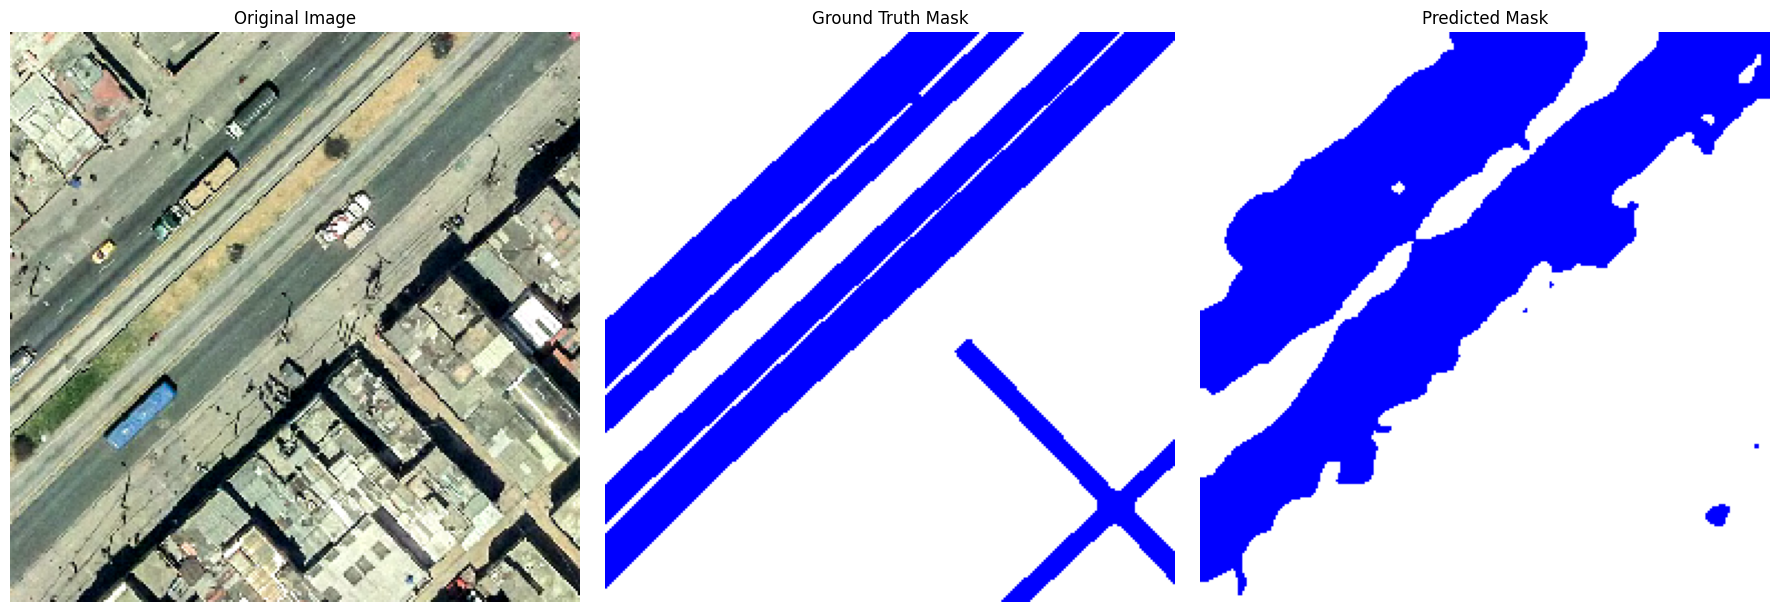

In [40]:
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

# Get a sample from the validation dataset
val_dataset = dataloader['val']

# Randomly select an index
idx = random.randint(0, len(val_dataset) - 1)

# Get the item from the dataset
sample = val_dataset[idx]
image_tensor = sample['pixel_values']
label_tensor = sample['labels']

# Retrieve the original image and label paths for better visualization reference
original_image_path = val_dataset.image_paths[idx]
original_label_path = val_dataset.label_paths[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
with rasterio.open(original_image_path) as src:
    original_image_np = src.read()
    original_image_np[original_image_np == src.nodata] = 0
    p2, p98 = np.percentile(original_image_np, (2, 98))
    original_image_np = np.clip(original_image_np, p2, p98)
    original_image_np = (original_image_np - p2) / (p98 - p2)
    # Transpose to (H, W, C) for display
    original_image_display = (original_image_np.transpose(1, 2, 0) * 255).astype(np.uint8)

# Move image tensor to the correct device for inference
inputs = image_tensor.unsqueeze(0).to(device) # Add batch dimension

# Perform inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Get predicted logits and convert to predicted labels
logits = outputs.logits

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = label_tensor.unsqueeze(0).cpu().numpy()

# Convert masks to color images using the defined function
colored_ground_truth = masks_to_colorimg(ground_truth_mask_np)
colored_prediction = masks_to_colorimg(predicted_mask_np.reshape(1, *predicted_mask_np.shape)) # Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

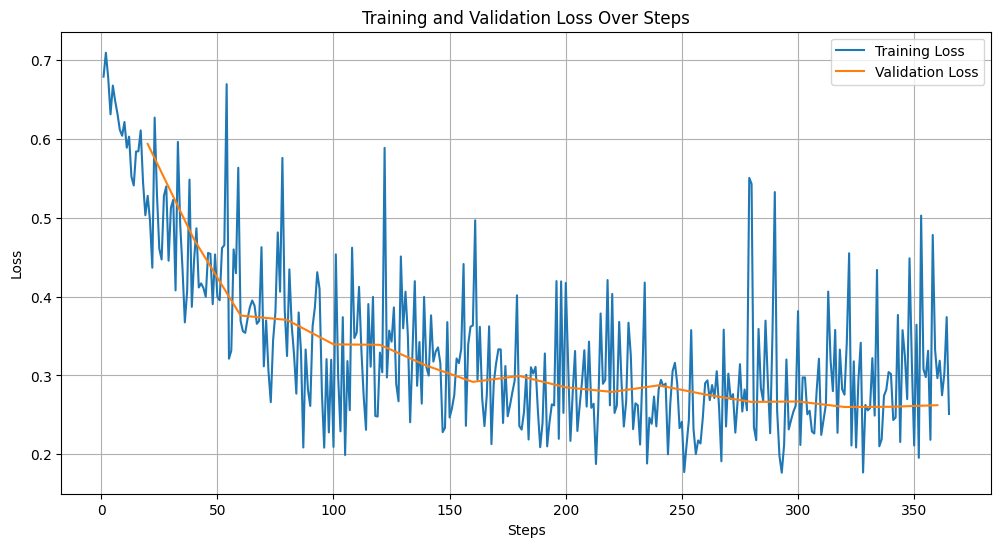

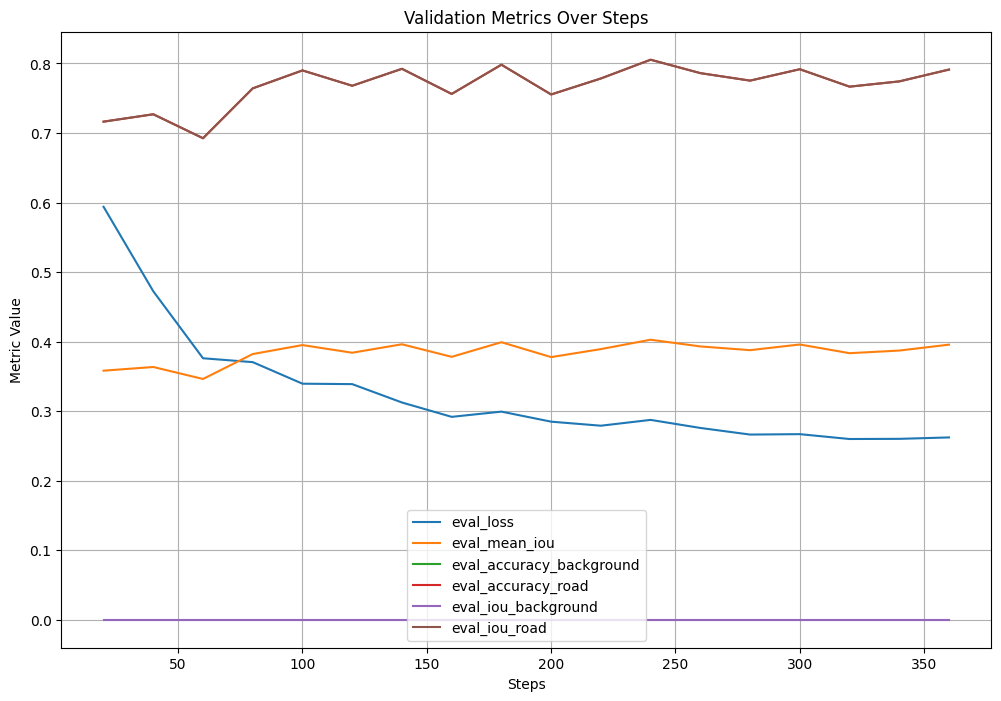

In [41]:
import matplotlib.pyplot as plt

# Extract training and evaluation logs
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
steps = []

# Metrics to plot
eval_metrics = {
    'eval_loss': [],
    'eval_mean_iou': [],
    'eval_accuracy_background': [],
    'eval_accuracy_road': [],
    'eval_iou_background': [],
    'eval_iou_road': [],
}

for log in log_history:
    if 'loss' in log: # Training loss
        train_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log: # Evaluation metrics
        eval_losses.append(log['eval_loss'])
        for key in eval_metrics.keys():
            if key in log:
                eval_metrics[key].append(log[key])

# Plotting training and evaluation loss
plt.figure(figsize=(12, 6))
plt.plot(steps[:len(train_losses)], train_losses, label='Training Loss')

# Match eval_losses to the steps where evaluation happened
eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
plt.plot(eval_steps, eval_losses, label='Validation Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Steps')
plt.legend()
plt.grid(True)
plt.show()

# Plotting evaluation metrics
plt.figure(figsize=(12, 8))
for metric_name, values in eval_metrics.items():
    if values: # Only plot if there are values for the metric
        plt.plot(eval_steps, values, label=metric_name)

plt.xlabel('Steps')
plt.ylabel('Metric Value')
plt.title('Validation Metrics Over Steps')
plt.legend()
plt.grid(True)
plt.show()

Visualizing probability heatmaps for 1 sample(s).


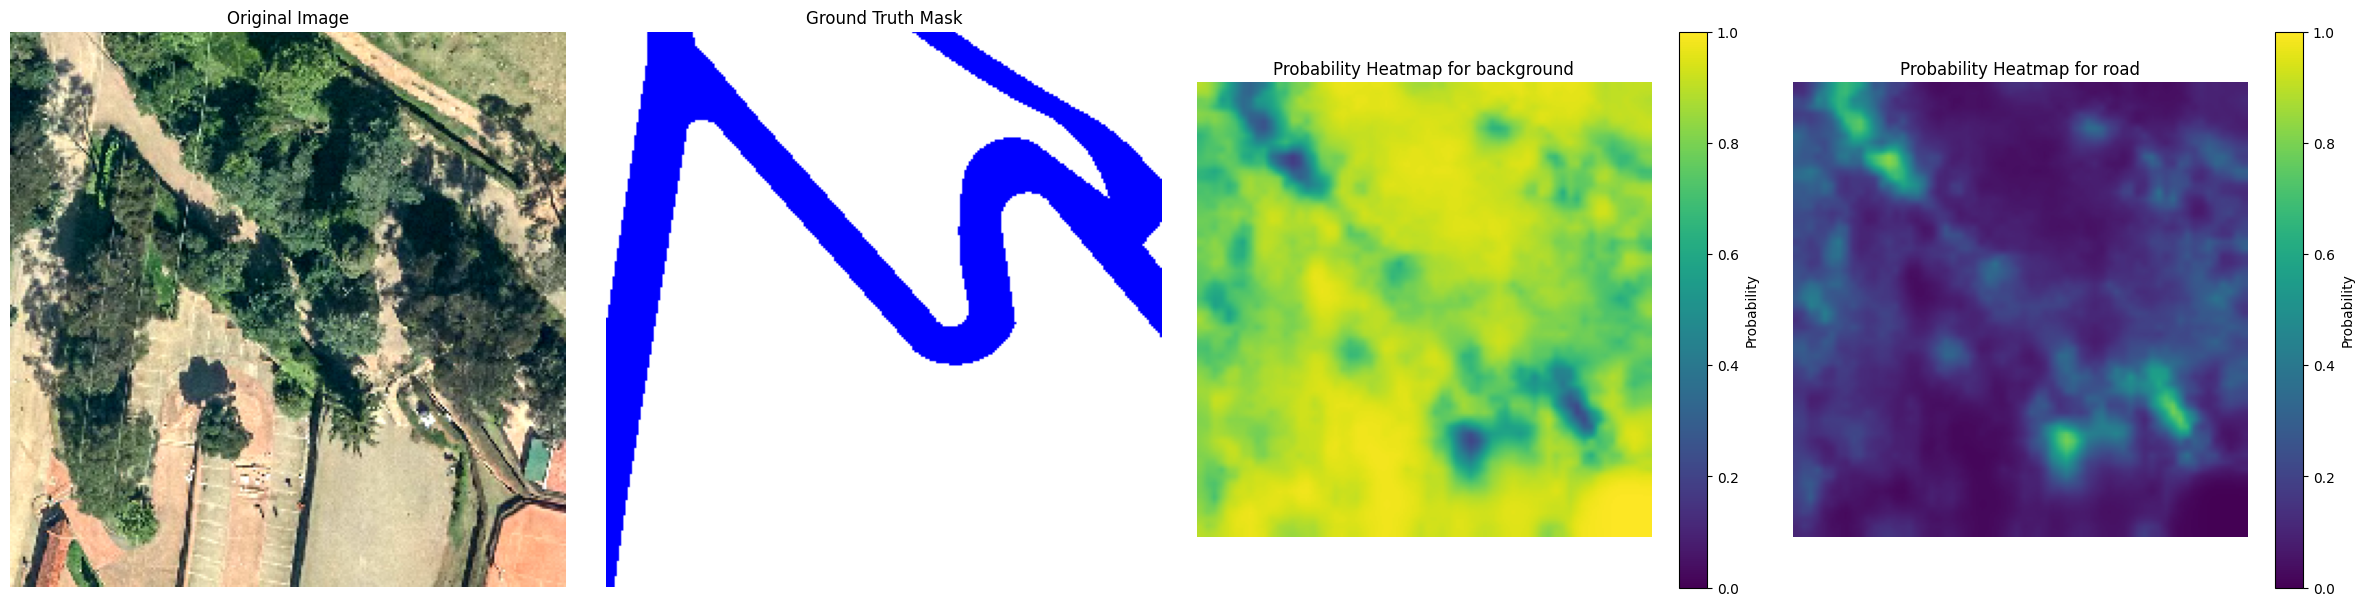

In [42]:
import matplotlib.pyplot as plt
import numpy as np
# Get a sample from the validation dataset
val_dataset = dataloader['val']

# Randomly select an index
idx = random.randint(0, len(val_dataset) - 1)

# Get the item from the dataset
sample = val_dataset[idx]
image_tensor = sample['pixel_values']
label_tensor = sample['labels']

# Retrieve the original image and label paths for better visualization reference
original_image_path = val_dataset.image_paths[idx]
original_label_path = val_dataset.label_paths[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
with rasterio.open(original_image_path) as src:
    original_image_np = src.read()
    original_image_np[original_image_np == src.nodata] = 0
    p2, p98 = np.percentile(original_image_np, (2, 98))
    original_image_np = np.clip(original_image_np, p2, p98)
    original_image_np = (original_image_np - p2) / (p98 - p2)
    # Transpose to (H, W, C) for display
    original_image_display = (original_image_np.transpose(1, 2, 0) * 255).astype(np.uint8)

# Move image tensor to the correct device for inference
inputs = image_tensor.unsqueeze(0).to(device) # Add batch dimension

# Perform inference
model.eval()
with torch.no_grad():
    outputs = model(inputs)

# Get predicted logits
logits = outputs.logits

# Resize logits to the original label size (from the dataset item)
interpolated_logits = torch.nn.functional.interpolate(
    logits,
    size=label_tensor.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
)

# Apply softmax to get probability maps for each class
probabilities = torch.nn.functional.softmax(interpolated_logits, dim=1).cpu().numpy()

# Unpack the shape of the probabilities tensor (batch_size is 1 here)
batch_size, num_classes, H, W = probabilities.shape

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = label_tensor.unsqueeze(0).cpu().numpy()
colored_ground_truth = masks_to_colorimg(ground_truth_mask_np)

print(f"Visualizing probability heatmaps for {batch_size} sample(s).")

# Since batch_size is 1 for this inference, we can directly access index 0
# We will plot the original image, ground truth, and the probability maps for each class

fig, axes = plt.subplots(1, num_classes + 2, figsize=(6 * (num_classes + 2), 6)) # Added 1 for ground truth

# Plot original image
axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot ground truth mask
axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

for class_idx in range(num_classes):
    class_name = id2label[class_idx]
    ax = axes[class_idx + 2] # Shifted by 2 to account for original image and ground truth
    im = ax.imshow(probabilities[0, class_idx, :, :], cmap='viridis', vmin=0, vmax=1) # Probabilities for the current class
    fig.colorbar(im, ax=ax, label='Probability')
    ax.set_title(f'Probability Heatmap for {class_name}')
    ax.axis('off')

plt.tight_layout()
plt.show()


In [43]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results

#calcualte metrics
dataloader = get_data_loaders()
# Get a sample from the validation dataset
val_loader = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=num_labels, class_names=list(id2label.values()), ignore_index=255)
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for batch in val_loader:
    inputs = batch["pixel_values"].to(device)
    labels = batch["labels"].to(device)

    # Ensure batch dimension exists
    if inputs.ndim == 3:   # [C,H,W] -> [1,C,H,W]
        inputs = inputs.unsqueeze(0)
    if labels.ndim == 2:   # [H,W] -> [1,H,W]
        labels = labels.unsqueeze(0)

    with torch.no_grad():
        # HF SegFormer forward is safest with named arg
        outputs = model(pixel_values=inputs)

    logits = outputs.logits
    if logits.ndim == 3:   # [C,H,W] -> [1,C,H,W] (safety)
        logits = logits.unsqueeze(0)
    outputs.logits

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)

    # labels are already 0 or 1 from TrainingDataset
    # No need for F.softmax or remap_labels as per user request and dataset prep

    # Update IoU metrics
    metrics_calculator.update(predicted_mask_tensor.cpu(), labels.cpu())

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])

Training images (using pre-undersampled drive): 730
Validation images: 183
using the one with binary segmentation
using the one with binary segmentation
Per-class IoU: {'background': np.float64(0.8627640491718752), 'road': np.float64(0.67613266130138)}
Per-class F1: {'background': np.float64(0.9263262129557109), 'road': np.float64(0.8067765266112653)}
Mean IoU: 0.7694483552366276
Mean F1: 0.8665513697834881
